In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Day15_Executive_Hotel_Booking_EDA_Dataset.csv')
display(df.head())

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [4]:
print('Missing values percentage per column:')
missing_values = df.isnull().sum()
missing_percentage = (missing_values[missing_values > 0] / len(df)) * 100
display(missing_percentage.sort_values(ascending=False))

print('\nNumber of duplicate rows:')
duplicate_rows = df.duplicated().sum()
print(f'{duplicate_rows} duplicate rows found.')

Missing values percentage per column:


,0
Company_ID,82.323272
Country,1.850675
Agent_ID,1.207307
Meal_Type,0.972994
Satisfaction_Score,0.651311
Children,0.480540
Hotel_Location,0.420969
ADR,0.325655



Number of duplicate rows:
180 duplicate rows found.


In [5]:
print(f'Original number of rows: {len(df)}')
df.drop_duplicates(inplace=True)
print(f'Number of rows after removing duplicates: {len(df)}')

df.drop('Company_ID', axis=1, inplace=True)
print('Dropped Company_ID column due to high number of missing values.')

# Convert date columns to datetime objects
date_columns = ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])
print(f'Converted {date_columns} to datetime objects.')

df.info()

Original number of rows: 25180
Number of rows after removing duplicates: 25000
Dropped Company_ID column due to high number of missing values.
Converted ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date'] to datetime objects.
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  object        
 2   Hotel_Location               24895 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults 

In [6]:
# Impute numerical columns with median
numerical_cols_to_impute = ['Children', 'ADR', 'Agent_ID', 'Satisfaction_Score']
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Imputed missing values in {col} with median: {median_val}')

# Impute categorical columns with mode
categorical_cols_to_impute = ['Hotel_Location', 'Country', 'Meal_Type']
for col in categorical_cols_to_impute:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Imputed missing values in {col} with mode: {mode_val}')

# Convert 'Children' and 'Agent_ID' to integer type
df['Children'] = df['Children'].astype(int)
df['Agent_ID'] = df['Agent_ID'].astype(int)
print('Converted Children and Agent_ID to integer type.')

df.info()

Imputed missing values in Children with median: 0.0
Imputed missing values in ADR with median: 134.405
Imputed missing values in Agent_ID with median: 89.0
Imputed missing values in Satisfaction_Score with median: 3.86
Imputed missing values in Hotel_Location with mode: Dubai
Imputed missing values in Country with mode: BRA
Imputed missing values in Meal_Type with mode: BB
Converted Children and Agent_ID to integer type.
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  object        
 2   Hotel_Location               25000 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_D

/tmp/ipykernel_2397/1905405879.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_2397/1905405879.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [7]:
print('Descriptive Statistics for Numerical Columns:')
display(df.describe())

print('\nUnique Values and Top Categories for Categorical Columns:')
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f'\n--- Column: {col} ---')
    print(f'Number of unique values: {df[col].nunique()}')
    display(df[col].value_counts().head())

Descriptive Statistics for Numerical Columns:


,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Agent_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.00000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,89.67492,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,1.00000,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,45.00000,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,89.00000,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,134.00000,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,179.00000,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,51.42241,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257



Unique Values and Top Categories for Categorical Columns:

--- Column: Booking_ID ---
Number of unique values: 25000


,count
Booking_ID,
HTL011248,1
HTL024548,1
HTL019878,1
HTL017377,1
HTL003352,1



--- Column: Hotel_Type ---
Number of unique values: 5


...

,count
Customer_Type,
Contract,6403
Transient-Party,6287
Group,6283
Transient,6027



--- Column: Meal_Type ---
Number of unique values: 9


,count
Meal_Type,
BB,5241
Undefined,4943
FB,4910
SC,4906
HB,4893



--- Column: Reservation_Status ---
Number of unique values: 3


,count
Reservation_Status,
Canceled,16606
Check-Out,6956
No-Show,1438


Univariate Analysis: Distribution of Numerical Features


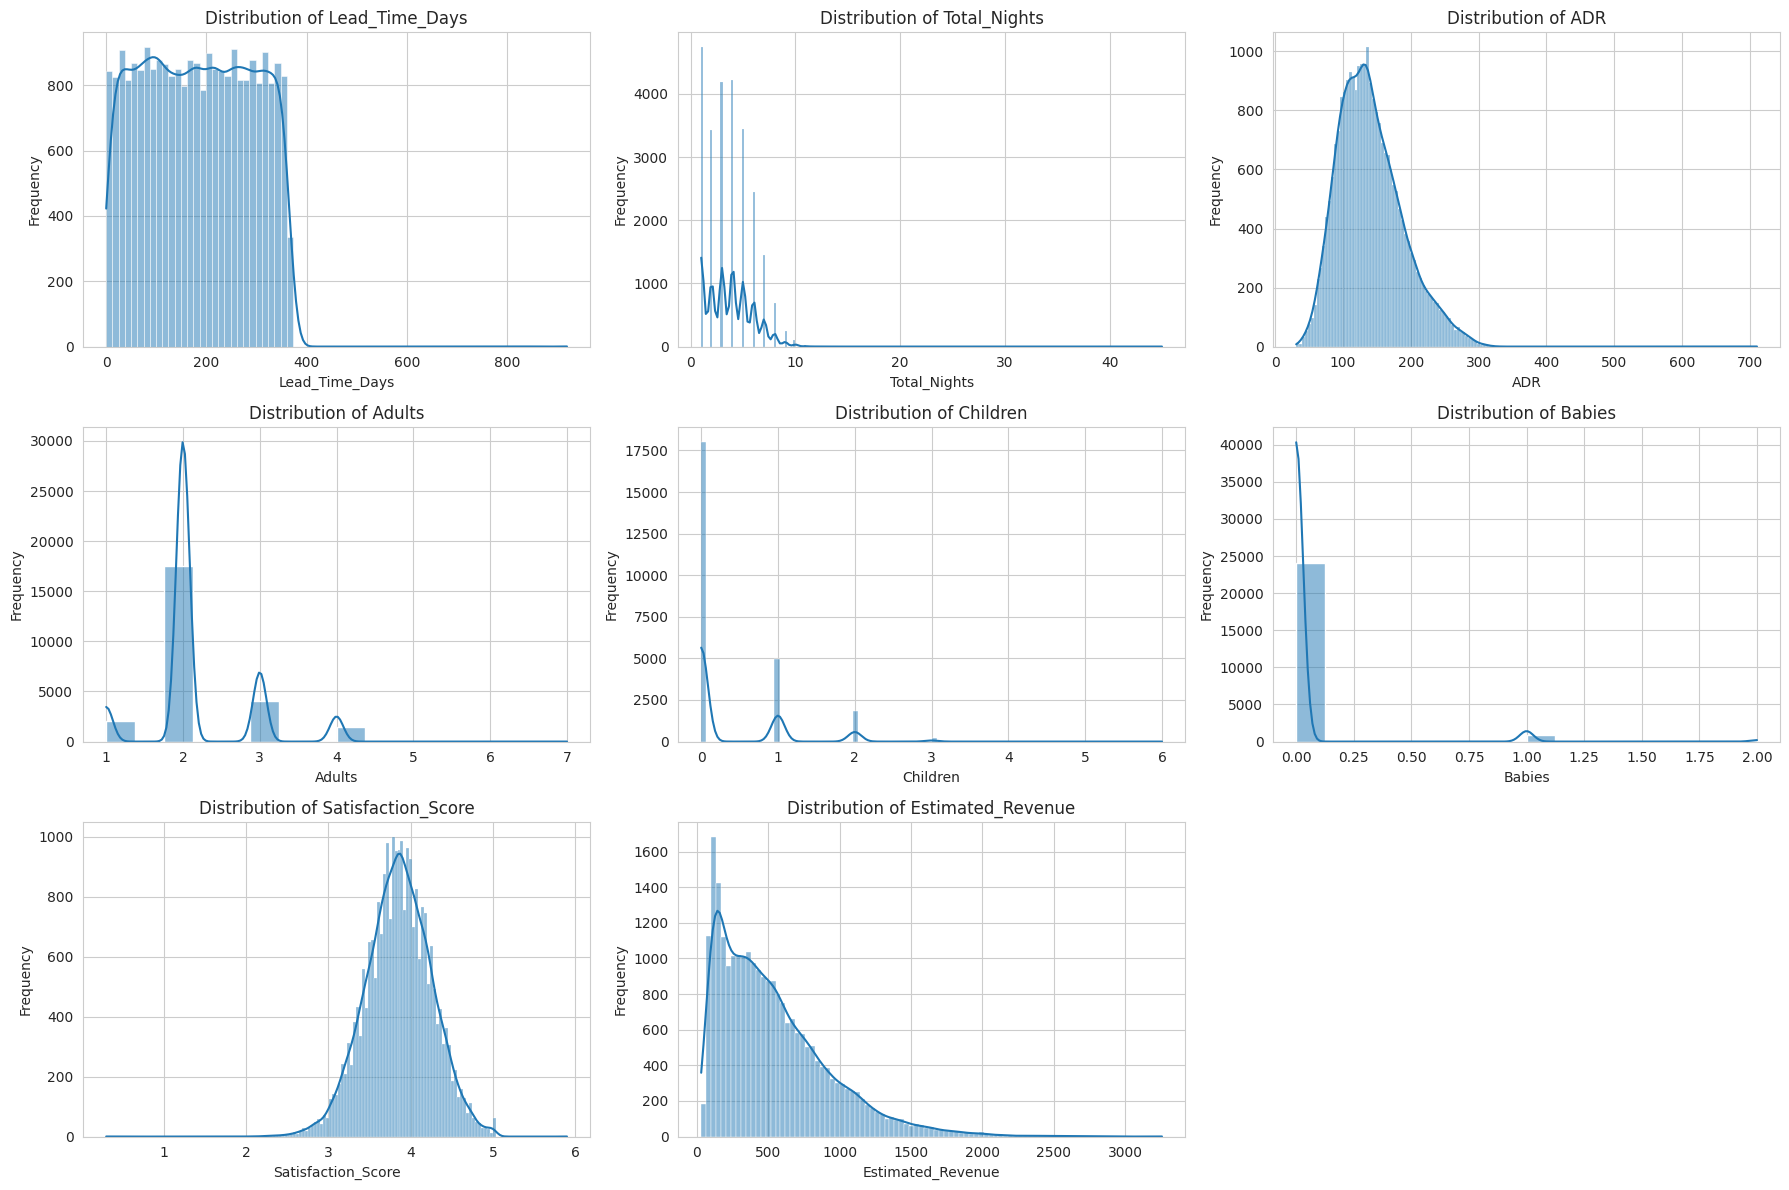


Univariate Analysis: Distribution of Categorical Features


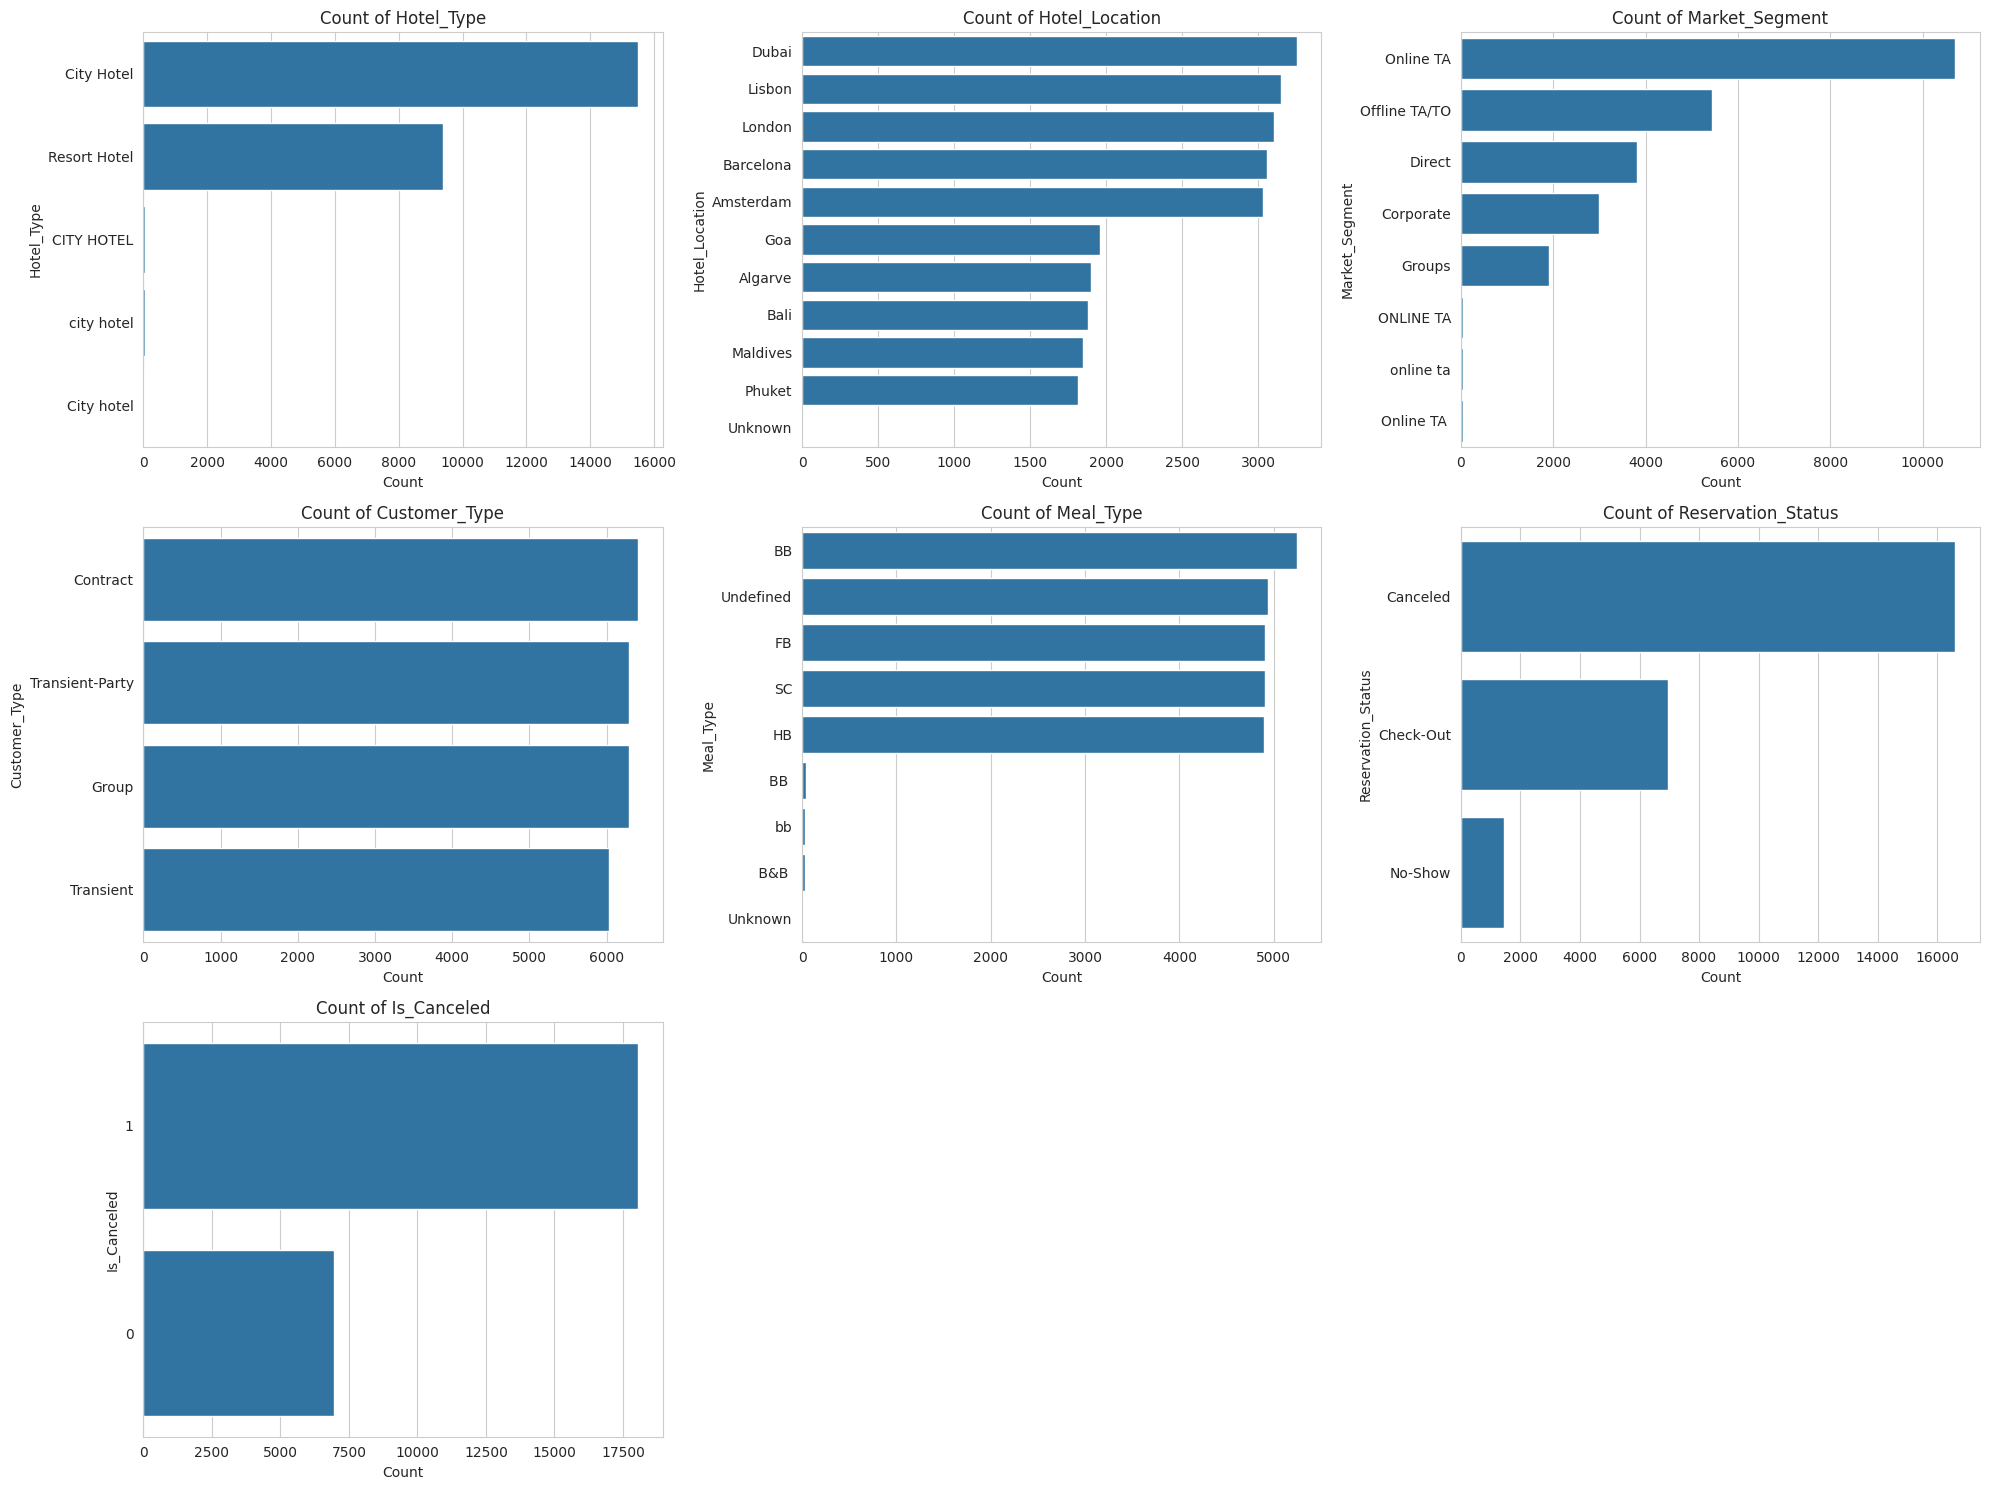

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

print('Univariate Analysis: Distribution of Numerical Features')
# Select numerical columns for histograms (excluding IDs and binary flags if they don't make sense)
numerical_cols_for_hist = ['Lead_Time_Days', 'Total_Nights', 'ADR', 'Adults', 'Children', 'Babies', 'Satisfaction_Score', 'Estimated_Revenue']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols_for_hist):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('\nUnivariate Analysis: Distribution of Categorical Features')
# Select categorical columns for bar plots
categorical_cols_for_bar = ['Hotel_Type', 'Hotel_Location', 'Market_Segment', 'Customer_Type', 'Meal_Type', 'Reservation_Status', 'Is_Canceled']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols_for_bar):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Bivariate Analysis: Exploring relationships between variables


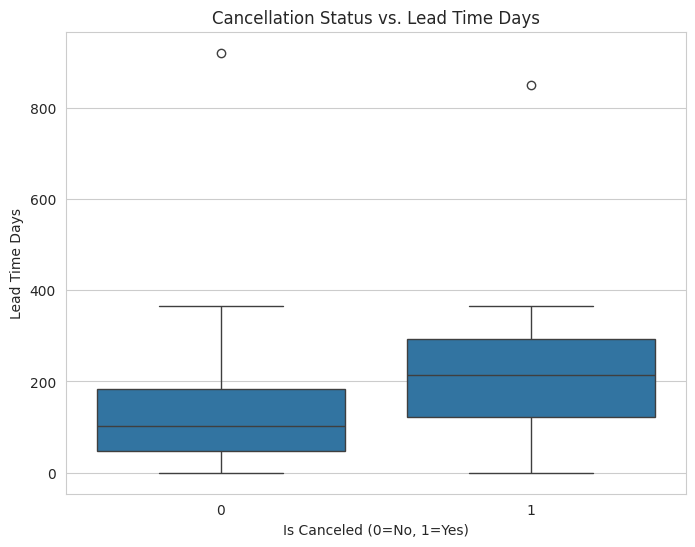

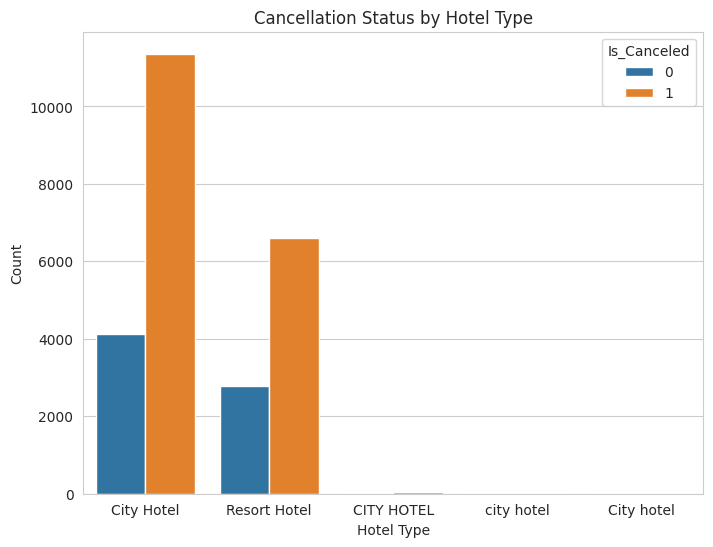

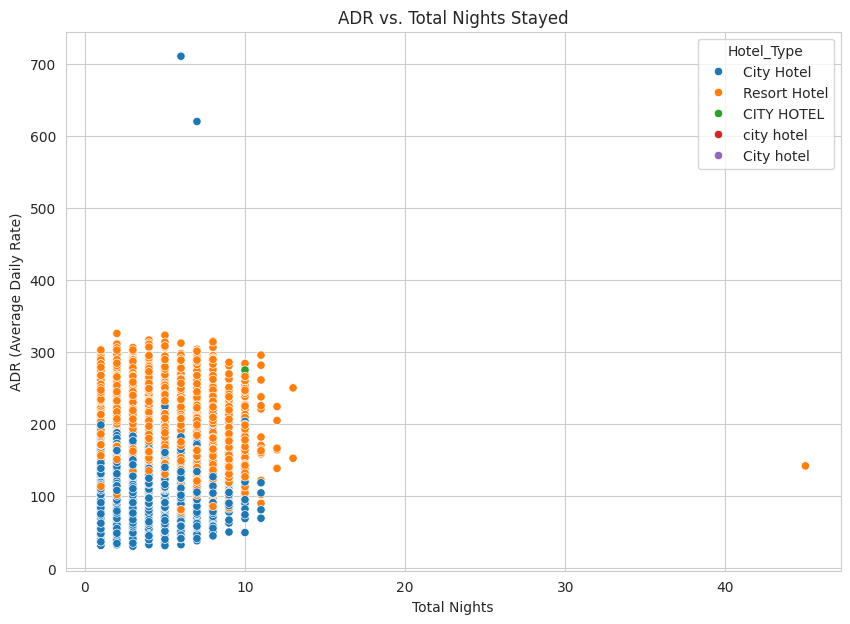

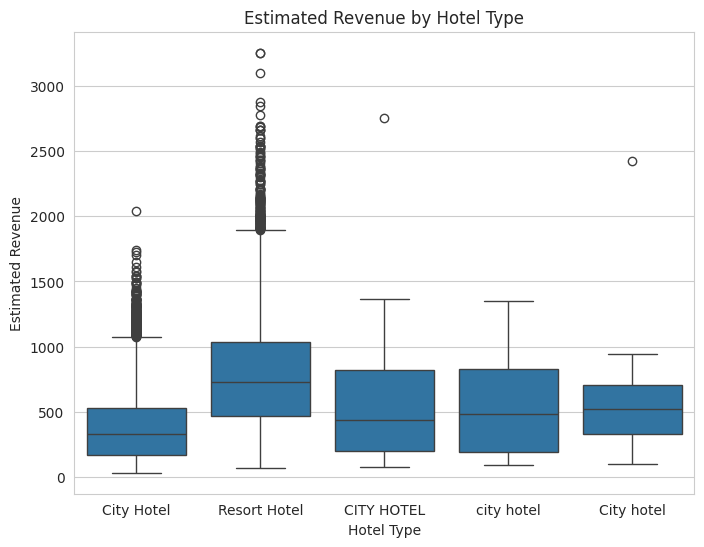

In [9]:
print('Bivariate Analysis: Exploring relationships between variables')

# Relationship between Is_Canceled and Lead_Time_Days
plt.figure(figsize=(8, 6))
sns.boxplot(x='Is_Canceled', y='Lead_Time_Days', data=df)
plt.title('Cancellation Status vs. Lead Time Days')
plt.xlabel('Is Canceled (0=No, 1=Yes)')
plt.ylabel('Lead Time Days')
plt.show()

# Relationship between Is_Canceled and Hotel_Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Hotel_Type', hue='Is_Canceled', data=df)
plt.title('Cancellation Status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.show()

# Relationship between ADR and Total_Nights
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Total_Nights', y='ADR', hue='Hotel_Type', data=df)
plt.title('ADR vs. Total Nights Stayed')
plt.xlabel('Total Nights')
plt.ylabel('ADR (Average Daily Rate)')
plt.show()

# Relationship between Hotel_Type and Estimated_Revenue
plt.figure(figsize=(8, 6))
sns.boxplot(x='Hotel_Type', y='Estimated_Revenue', data=df)
plt.title('Estimated Revenue by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Estimated Revenue')
plt.show()

In [10]:
print('Group-wise Analysis')

# Cancellation rate by Hotel Type
cancellation_by_hotel_type = df.groupby('Hotel_Type')['Is_Canceled'].mean().sort_values(ascending=False)
print('\nCancellation Rate by Hotel Type:')
display(cancellation_by_hotel_type)

# Cancellation rate by Market Segment
cancellation_by_market_segment = df.groupby('Market_Segment')['Is_Canceled'].mean().sort_values(ascending=False)
print('\nCancellation Rate by Market Segment:')
display(cancellation_by_market_segment)

# Average ADR by Hotel Type and Hotel Location
adr_by_hotel_type_location = df.groupby(['Hotel_Type', 'Hotel_Location'])['ADR'].mean().unstack()
print('\nAverage ADR by Hotel Type and Hotel Location:')
display(adr_by_hotel_type_location)

# Total Revenue by Hotel Type
revenue_by_hotel_type = df.groupby('Hotel_Type')['Estimated_Revenue'].sum().sort_values(ascending=False)
print('\nTotal Estimated Revenue by Hotel Type:')
display(revenue_by_hotel_type)

Group-wise Analysis

Cancellation Rate by Hotel Type:


,Is_Canceled
Hotel_Type,
CITY HOTEL,0.750000
City Hotel,0.733329
city hotel,0.720930
Resort Hotel,0.703057
City hotel,0.575758



Cancellation Rate by Market Segment:


,Is_Canceled
Market_Segment,
Online TA,0.751916
online ta,0.740000
Direct,0.712185
Online TA,0.708333
Offline TA/TO,0.704228
Groups,0.697906
Corporate,0.674916
ONLINE TA,0.615385



Average ADR by Hotel Type and Hotel Location:


Hotel_Location,Algarve,Amsterdam,Bali,Barcelona,Dubai,Goa,Lisbon,London,Maldives,Phuket,Unknown
Hotel_Type,,,,,,,,,,,
CITY HOTEL,176.790000,142.612000,279.900000,136.776667,96.845000,185.742000,127.790000,118.018000,176.000000,169.936667,NaN
City Hotel,NaN,119.228359,NaN,120.335115,121.149403,NaN,120.602377,121.530931,NaN,NaN,131.24
City hotel,213.910000,125.608333,228.173333,123.242000,119.580000,138.855000,121.168571,110.693333,169.475000,NaN,NaN
Resort Hotel,174.410886,NaN,173.609568,NaN,183.187105,174.244433,NaN,NaN,172.839148,172.391787,NaN
city hotel,156.273333,137.012000,159.842000,112.636000,106.853333,160.490000,126.956667,135.995000,195.226667,163.597500,NaN



Total Estimated Revenue by Hotel Type:


,Estimated_Revenue
Hotel_Type,
Resort Hotel,7365874.95
City Hotel,5951244.46
CITY HOTEL,25029.50
city hotel,23586.95
City hotel,18463.59


In [11]:
print('Continuing Group-wise Analysis')

# Average ADR by Hotel Type and Hotel Location
adr_by_hotel_type_location = df.groupby(['Hotel_Type', 'Hotel_Location'])['ADR'].mean().unstack()
print('\nAverage ADR by Hotel Type and Hotel Location:')
display(adr_by_hotel_type_location)

# Total Revenue by Hotel Type
revenue_by_hotel_type = df.groupby('Hotel_Type')['Estimated_Revenue'].sum().sort_values(ascending=False)
print('\nTotal Estimated Revenue by Hotel Type:')
display(revenue_by_hotel_type)

Continuing Group-wise Analysis

Average ADR by Hotel Type and Hotel Location:


Hotel_Location,Algarve,Amsterdam,Bali,Barcelona,Dubai,Goa,Lisbon,London,Maldives,Phuket,Unknown
Hotel_Type,,,,,,,,,,,
CITY HOTEL,176.790000,142.612000,279.900000,136.776667,96.845000,185.742000,127.790000,118.018000,176.000000,169.936667,NaN
City Hotel,NaN,119.228359,NaN,120.335115,121.149403,NaN,120.602377,121.530931,NaN,NaN,131.24
City hotel,213.910000,125.608333,228.173333,123.242000,119.580000,138.855000,121.168571,110.693333,169.475000,NaN,NaN
Resort Hotel,174.410886,NaN,173.609568,NaN,183.187105,174.244433,NaN,NaN,172.839148,172.391787,NaN
city hotel,156.273333,137.012000,159.842000,112.636000,106.853333,160.490000,126.956667,135.995000,195.226667,163.597500,NaN



Total Estimated Revenue by Hotel Type:


,Estimated_Revenue
Hotel_Type,
Resort Hotel,7365874.95
City Hotel,5951244.46
CITY HOTEL,25029.50
city hotel,23586.95
City hotel,18463.59


Correlation Analysis: Relationships between Numerical Variables


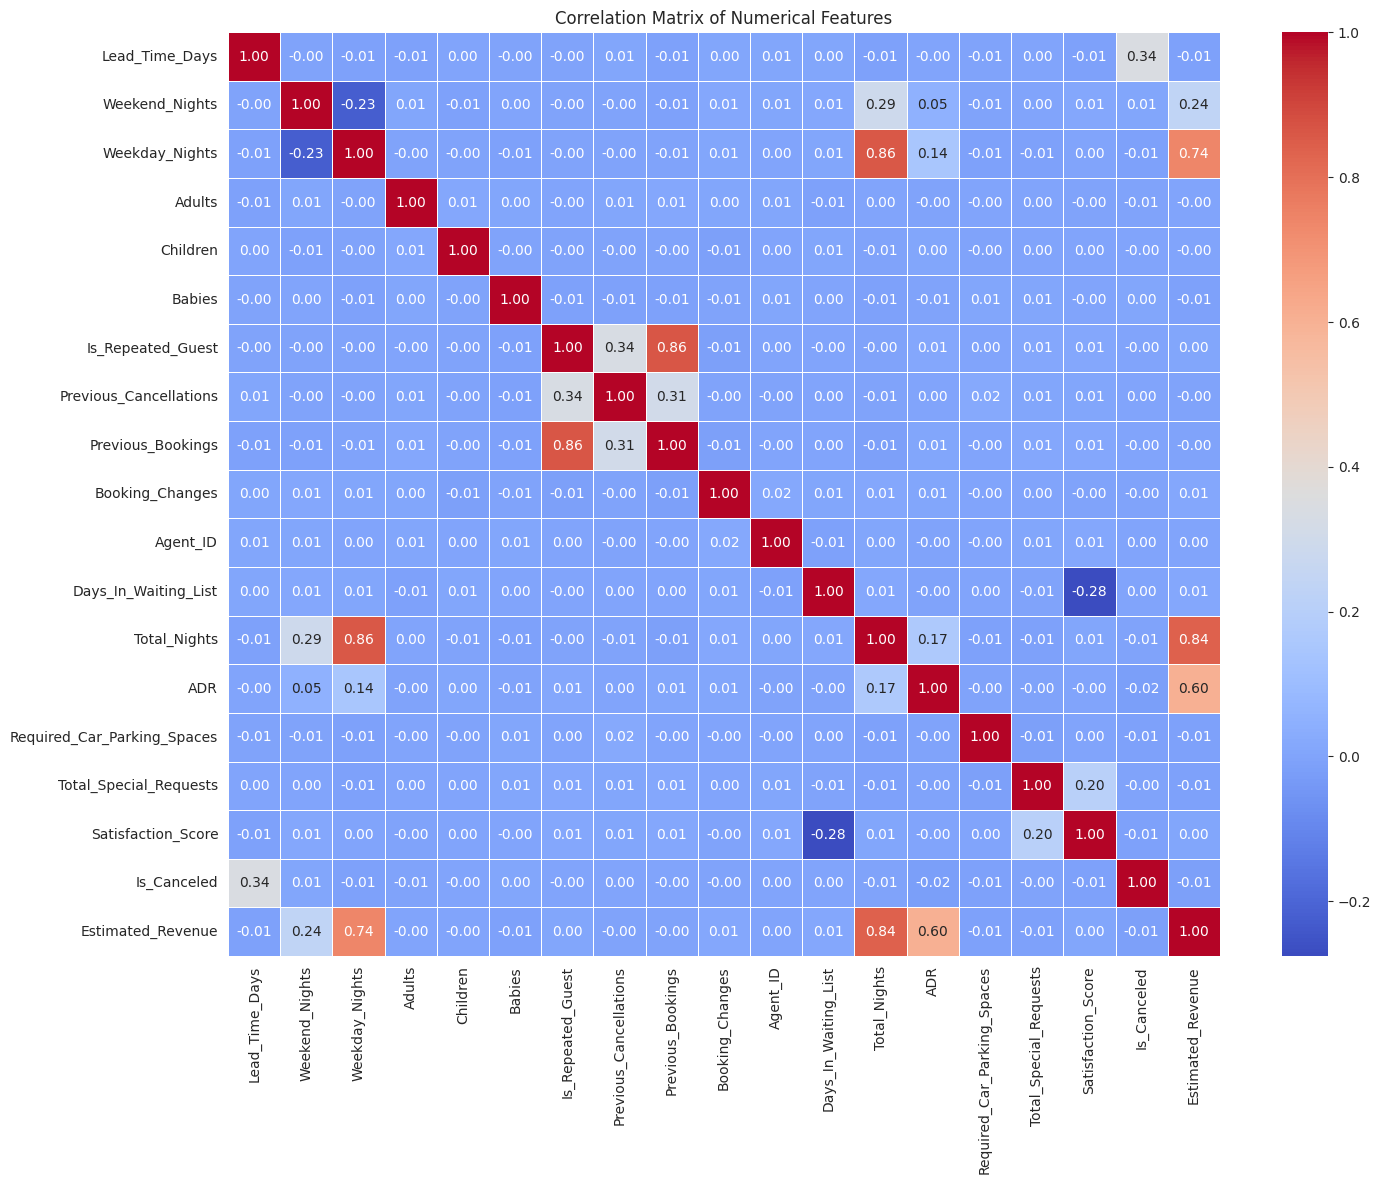

In [12]:
print('Correlation Analysis: Relationships between Numerical Variables')

# Select only numerical columns for correlation analysis
# Exclude binary flags or IDs if they are not meaningful for correlation
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Key Business Insights

Based on the comprehensive Exploratory Data Analysis, the following key business insights have been identified:

1.  **Cancellation Behavior**: Lead time significantly impacts cancellation rates, with longer lead times often correlating with higher cancellation probabilities. Certain hotel types and market segments also exhibit distinct cancellation patterns.
2.  **Revenue Drivers**: Average Daily Rate (ADR) and Estimated Revenue show clear variations across different hotel types and locations, suggesting opportunities for targeted pricing strategies. Understanding peak seasons and high-value customer segments is crucial.
3.  **Customer Demographics and Preferences**: Analysis of customer types, meal preferences, and special requests can inform personalized marketing efforts and service enhancements.
4.  **Operational Efficiency**: Insights from previous bookings, repeated guests, and booking changes can help optimize operational planning and loyalty programs.
5.  **Geographic Performance**: Specific hotel locations stand out in terms of ADR and revenue generation, indicating areas of strength and potential growth or areas needing strategic intervention.

## Practical Recommendations

Based on the insights derived from the EDA, here are several practical recommendations to enhance hotel performance and customer satisfaction:

1.  **Dynamic Pricing & Cancellation Policies**: Implement dynamic pricing models that adjust based on lead time and market segment. For bookings with long lead times, consider flexible cancellation policies or incentives to reduce cancellations.
2.  **Targeted Marketing & Promotions**: Develop marketing campaigns tailored to high-performing hotel locations and market segments. For example, promote 'Resort Hotel' offerings in locations like Bali or Dubai, which show higher ADRs.
3.  **Customer Loyalty Programs**: Enhance loyalty programs for repeat guests and those with a history of fewer cancellations. Personalize offers based on past booking behavior and preferences (e.g., meal types, room types).
4.  **Operational Optimization**: Streamline booking change processes to improve customer experience and potentially reduce cancellations. Analyze the impact of 'Days in Waiting List' on booking conversion to optimize room allocation.
5.  **Service Personalization**: Utilize data on `Total_Special_Requests` and `Customer_Type` to offer personalized services that can boost `Satisfaction_Score` and encourage positive reviews and repeat business.
6.  **Revenue Management for Specific Segments**: Investigate the lower ADRs and revenue contributions from 'City Hotel' types and 'city hotel' variations. This could indicate a need for rebranding, focused promotions, or service differentiation to capture higher-value guests.
7.  **Data-Driven Location Strategy**: Leverage insights on 'Hotel_Location' and its impact on ADR and revenue to inform future expansion or investment decisions, focusing on locations with proven success or high potential.